In [1]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

c:\Users\meesa\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(model = "llama-3.1-8b-instant")

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

def chat_node(state: ChatState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

In [4]:
checkpointer = InMemorySaver()

graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

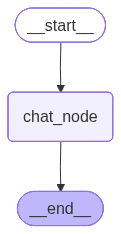

In [6]:
chatbot = graph.compile(checkpointer=checkpointer)
graph.compile(checkpointer=checkpointer)

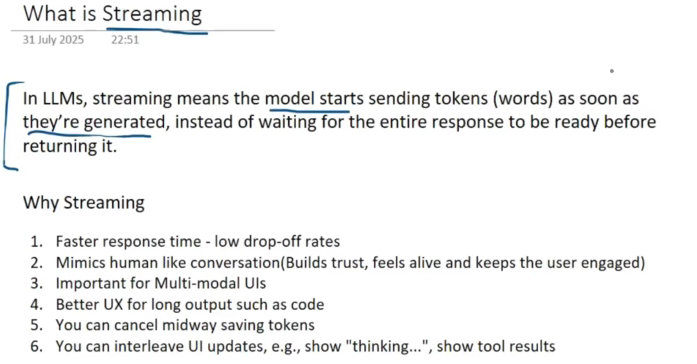